In [ ]:
! pip3 install numpy==1.23.5
! pip3 install pandas==2.0.1
! pip3 install scanpy==1.9.3
! pip3 install bokeh==3.0.3
! pip3 install selenium==4.33.0
! pip3 install seaborn==0.13.2

# 0. Library and settings

In [1]:
# Library
import warnings
warnings.simplefilter('ignore')

import pickle
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.collections import PolyCollection
from matplotlib.legend_handler import HandlerTuple
import seaborn as sns

In [ ]:
# Make directories
os.makedirs('Fig', exist_ok=True)
os.makedirs('Fig/Fig1(c)', exist_ok=True)

In [ ]:
# Figure number definitions
Fig1c = f'Fig/Figure1(c)'
FigS1 = f'Fig/Supplementary_Figure1'

# 1. Cluster definitions

In [4]:
with open("cluster_def_by_monocle_final.v2.1.rev.pkl", "rb") as tf:
    cdef = pickle.load(tf)

# 2. Loading data

In [5]:
def load_data(tissue):
    return sc.read_10x_mtx(
        f'Seurat/{tissue}/data2/',
        var_names='gene_symbols',
        cache=True
    )

# 3. Make dataframe

In [129]:
def make_df(adata, cdef, gene, clusters):
    idxes = adata[:, gene].obs.index.tolist()
    values = list(adata[:, gene].X.toarray().T[0])

    legend_map = {
        1:"Art", # Art
        3:"CapEC2'", # CapEC2'
        4:"CapEC2", # CapEC2
        5:"CapEC1", # CapEC1
        6:"CRP", # CRP
        7:"TrEC", # TrEC
        8:"HEC", # HEC
        9:"Vn", # Vn
    }
    
    X = []
    for cn in clusters:
        barcodes = [b[:-2] for b in cdef.keys() if cdef[b] == cn]
        X.append([legend_map[cn], 0.01])
        for idx, v in zip(idxes, values):
            if idx in barcodes:
                X.append([legend_map[cn], v])
    
    df = pd.DataFrame(X)
    df.columns = ['Cluster', gene]
    
    return df

# 4. Violin plot

In [259]:
def violin_plot(df, tissue, gene, y_min, y_max, y_unit, save_path):
    # settings
    plt.figure(figsize=(10, 5))
    plt.rcParams["font.size"] = 30
    plt.rc("axes", labelsize=40)
    plt.rc("xtick", labelsize=40)
    
    # Violin plot
    ax = sns.violinplot(x="Cluster", y=gene, palette=['1.0', '1'], width=.95, data=df)
    # x-axis
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    # y-axis
    ax.set(xlabel ='', ylabel=tissue, ylim=(y_min, y_max))
    ax.set_yticks([y_unit * i for i in range(4)]) 
    # Custom colors
    colors = ["#D0021B", "#FF789B", "#BA98FF", "#50E3C2", "#7ED321", "#4A90E2", "#F5A623", "#9013FE"]
    handles = []
    for ind, violin in enumerate(ax.findobj(PolyCollection)):
        rgb = to_rgb(colors[ind])
        violin.set_facecolor(rgb)
    # Strip plot
    sns.stripplot(data=df, x='Cluster', y=gene, color='black', size=3)
    
    # Save and show
    plt.subplots_adjust(bottom=0.5, top=0.95, right=0.95, left=0.25)
    plt.savefig(save_path)
    plt.show()

# 5. Plots

############### Chst4 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


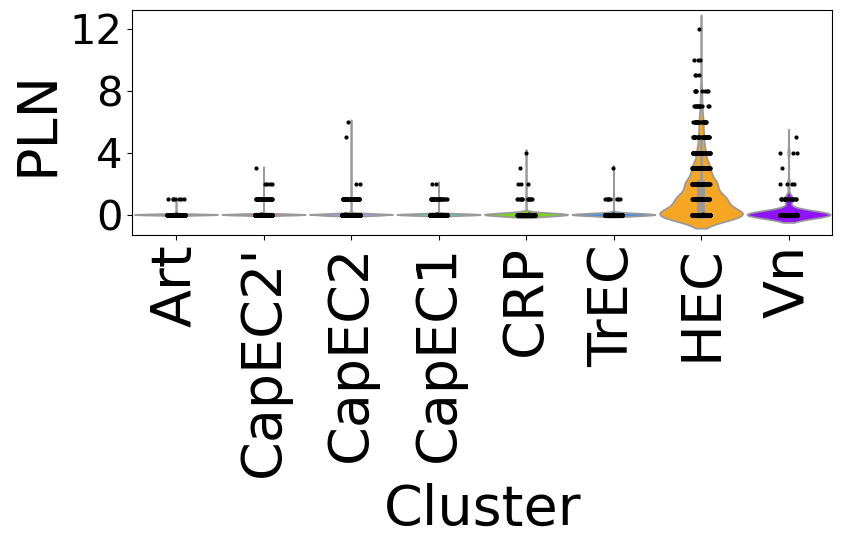

--------------- MLN ---------------


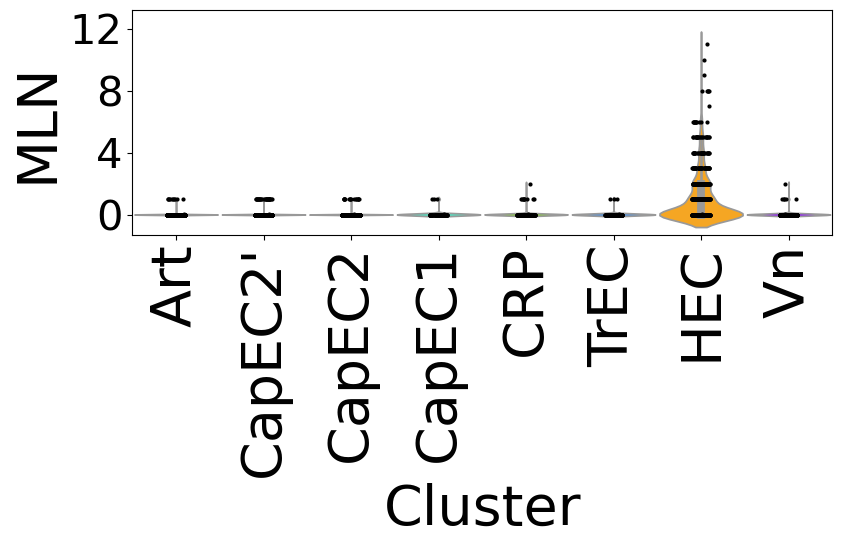

--------------- PP ---------------


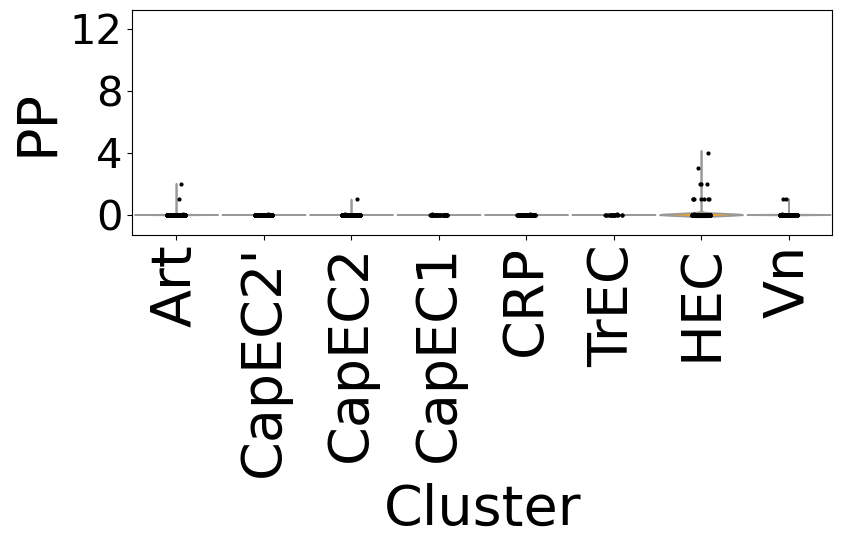

############### Fut7 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


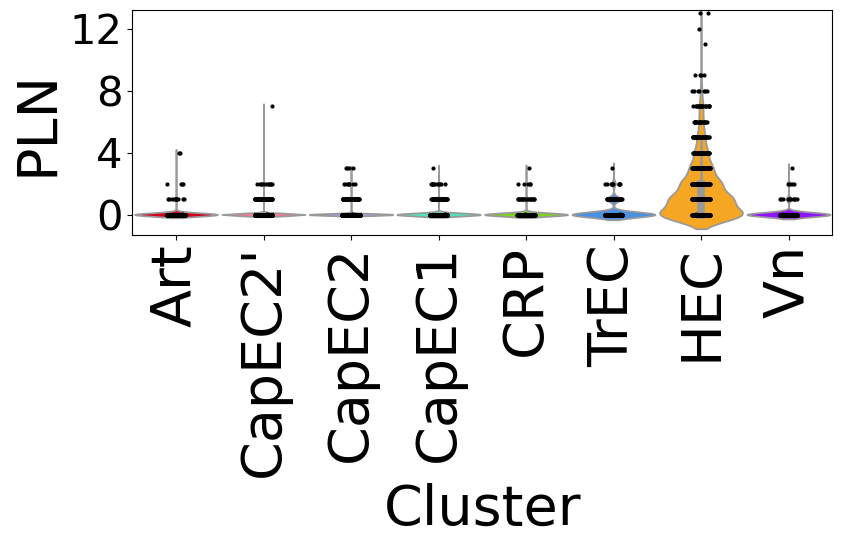

--------------- MLN ---------------


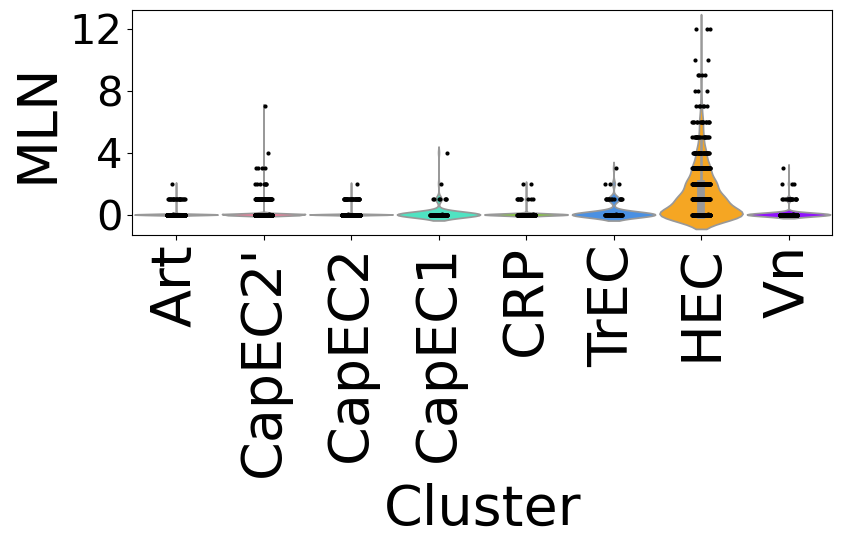

--------------- PP ---------------


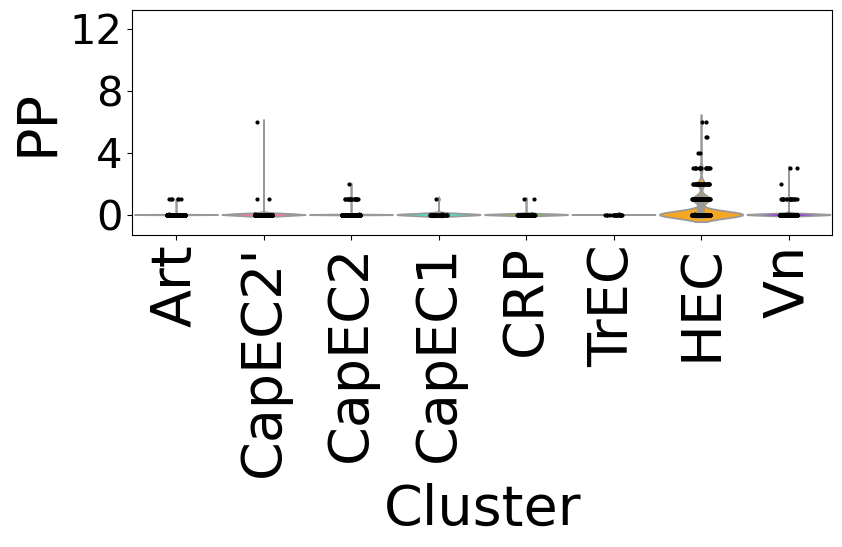

############### Gcnt1 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


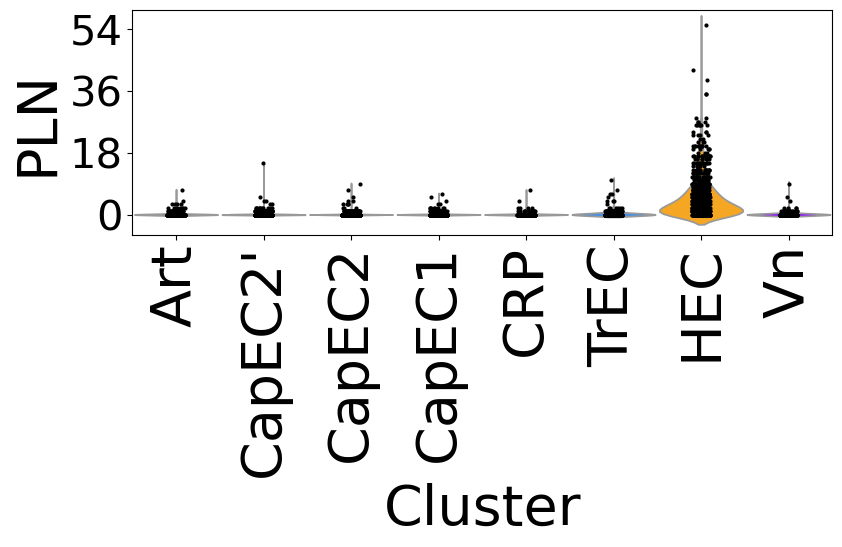

--------------- MLN ---------------


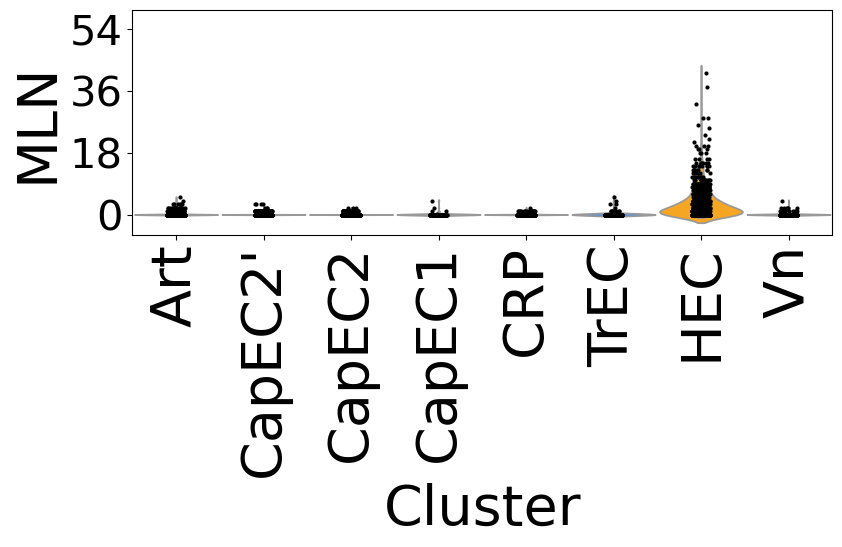

--------------- PP ---------------


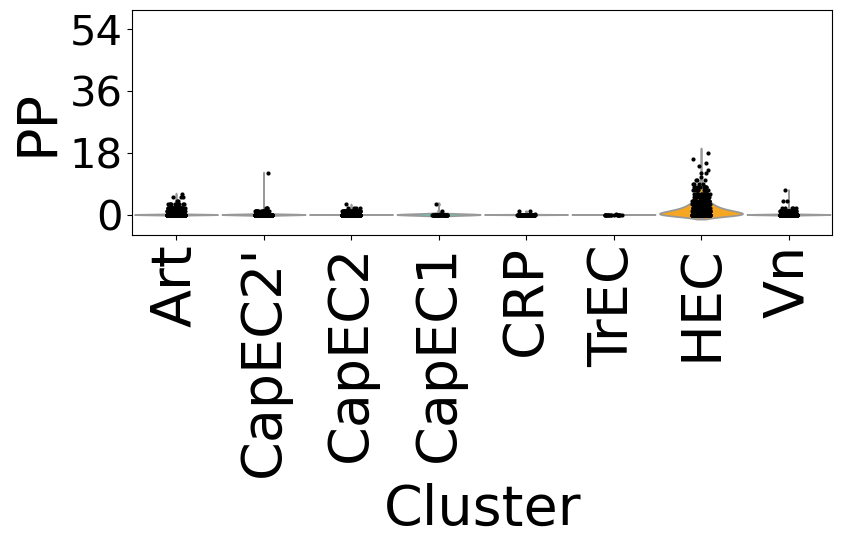

############### Glycam1 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


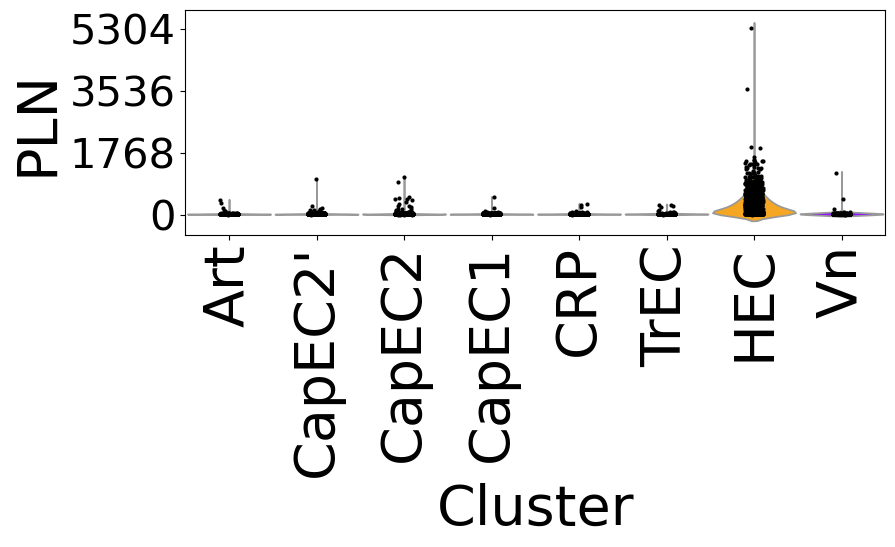

--------------- MLN ---------------


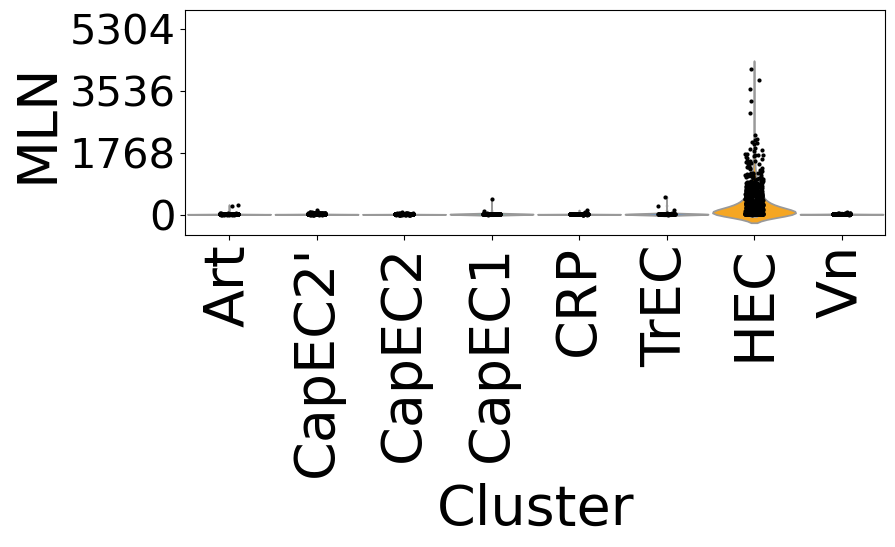

--------------- PP ---------------


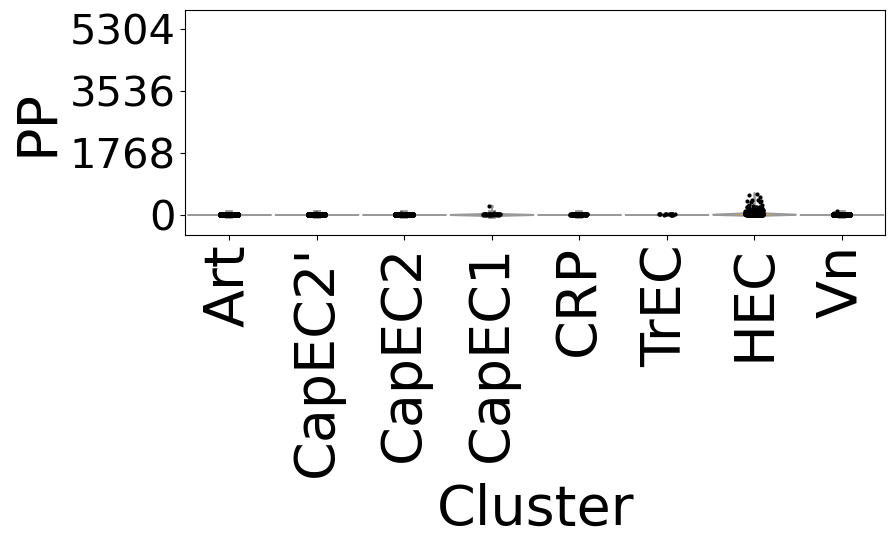

############### Csmd1 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


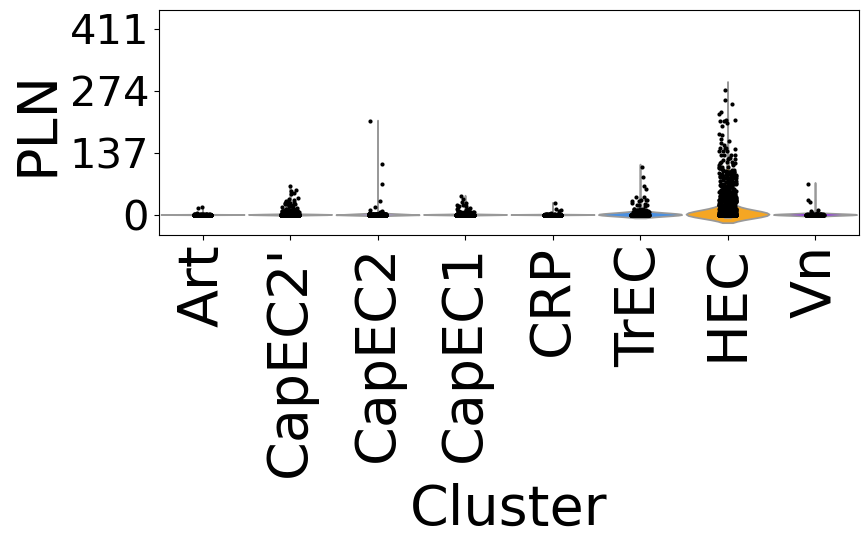

--------------- MLN ---------------


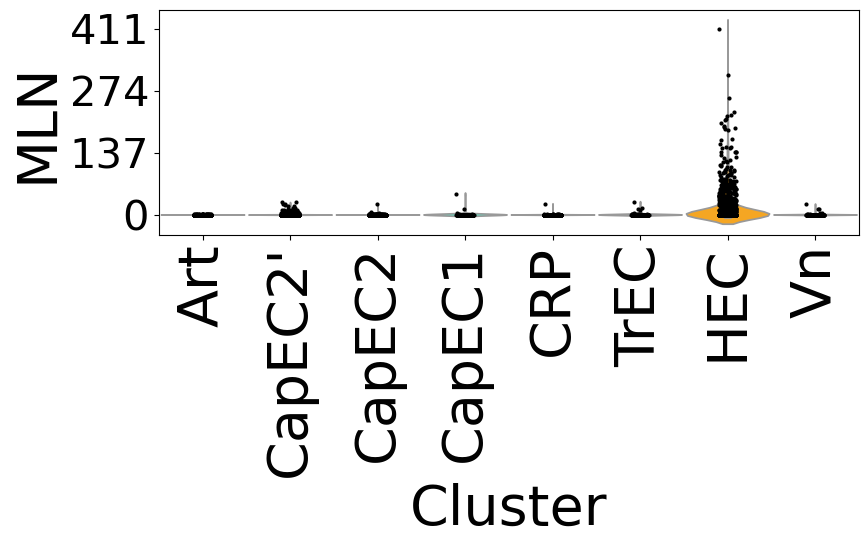

--------------- PP ---------------


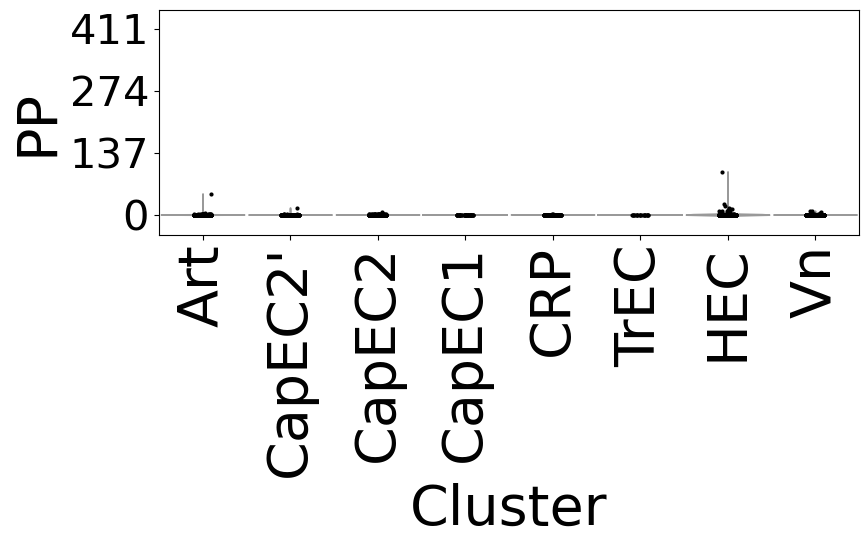

############### Clu ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


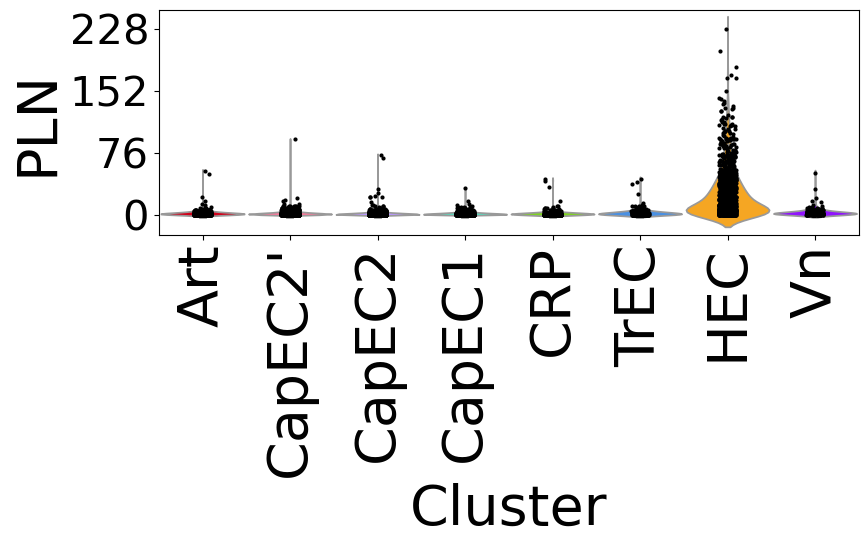

--------------- MLN ---------------


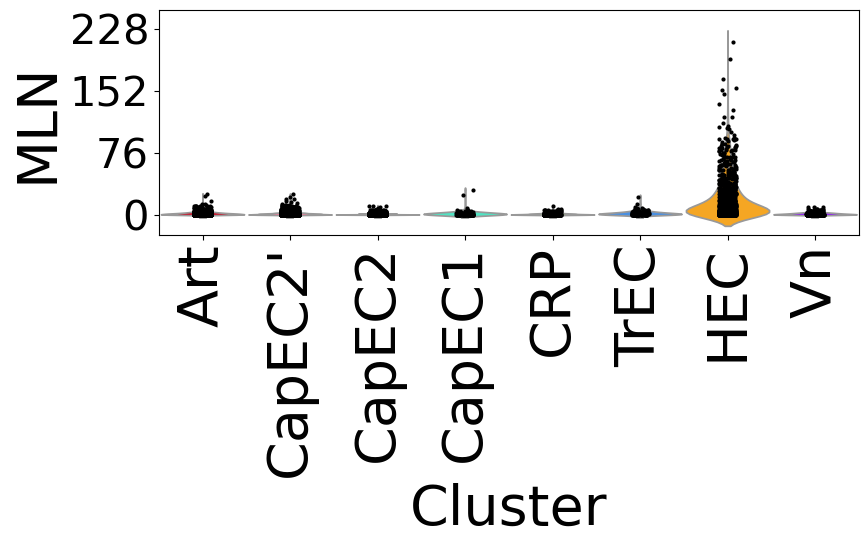

--------------- PP ---------------


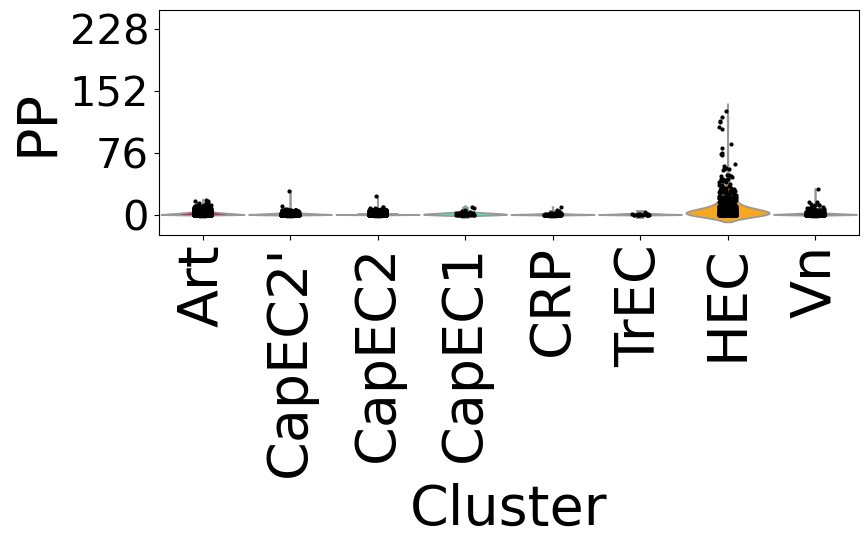

############### Ttn ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


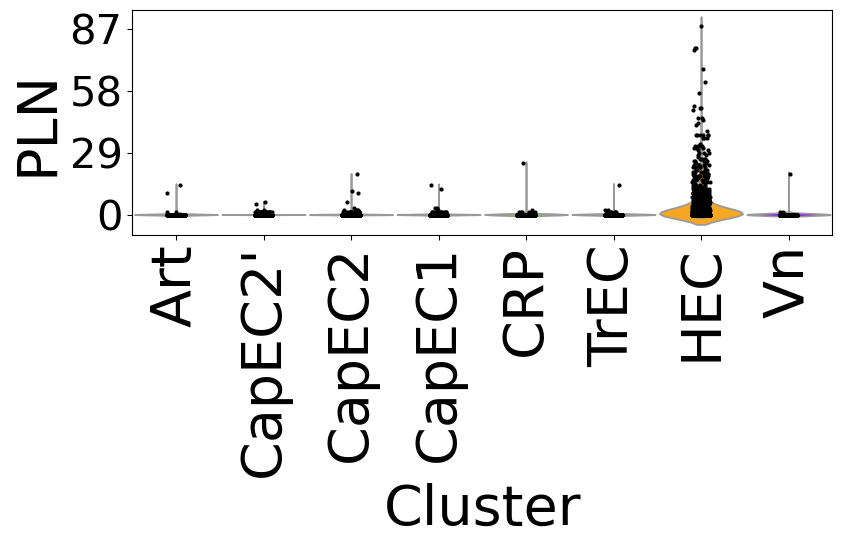

--------------- MLN ---------------


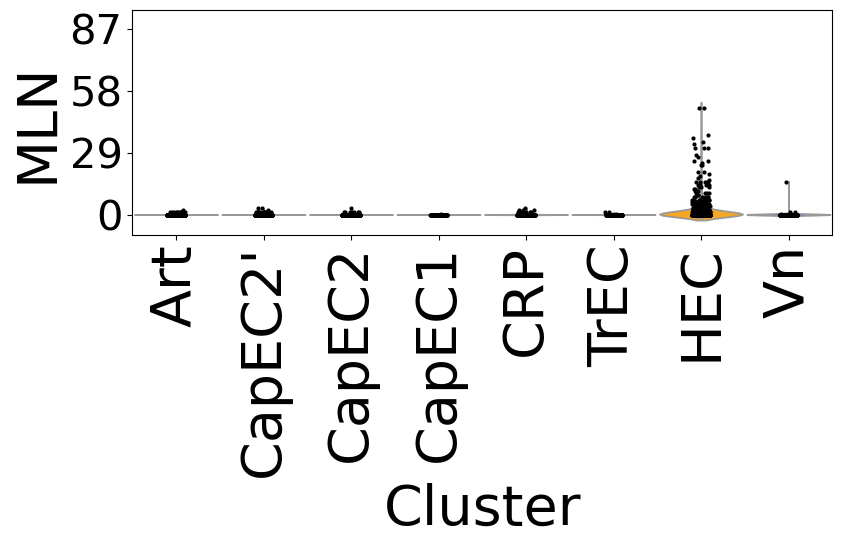

--------------- PP ---------------


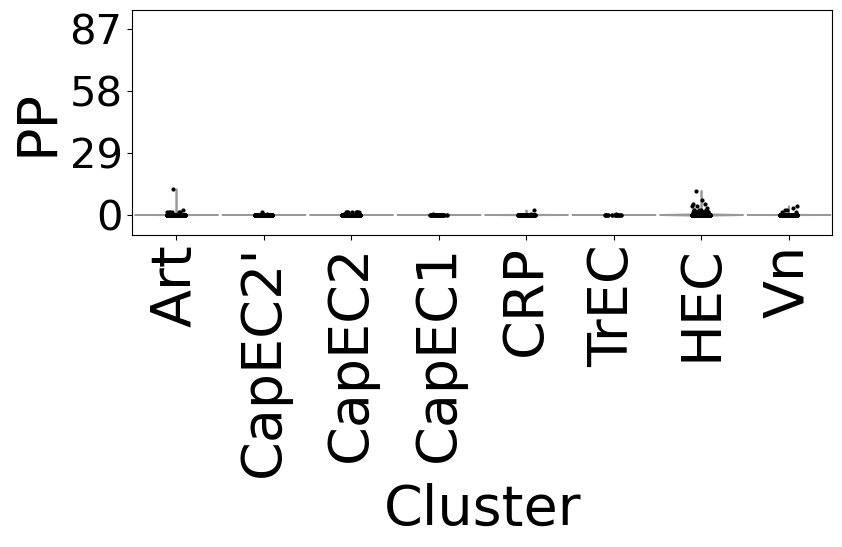

############### Ndst3 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


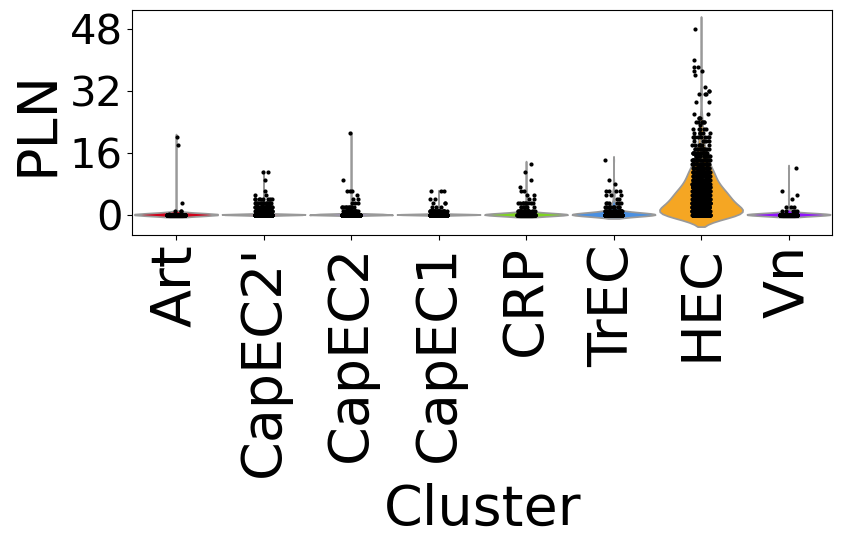

--------------- MLN ---------------


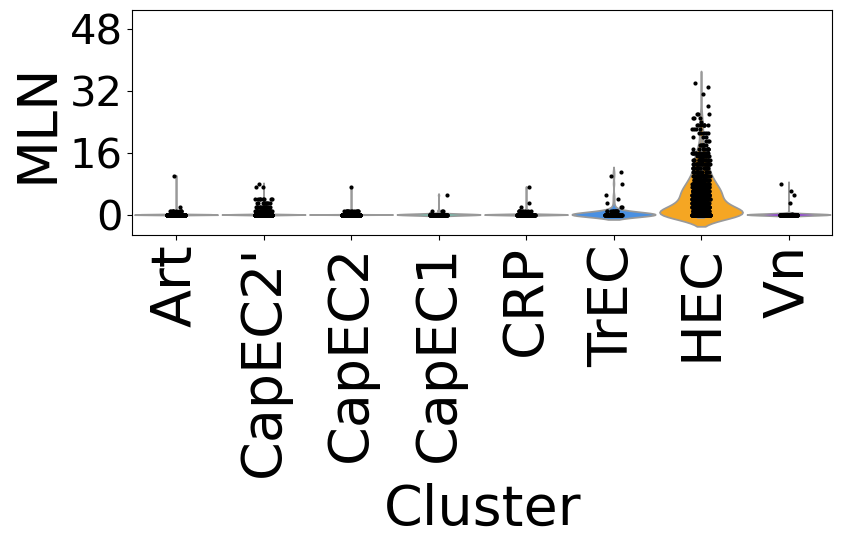

--------------- PP ---------------


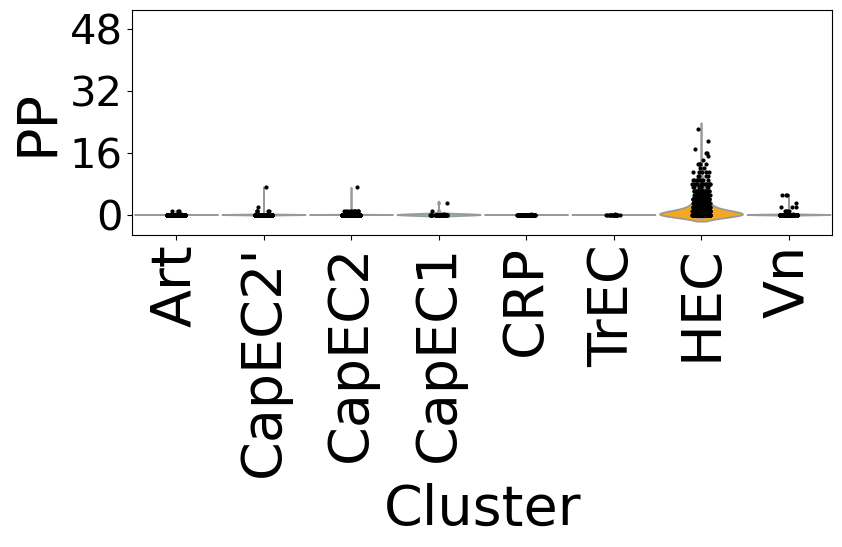

############### Robo1 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


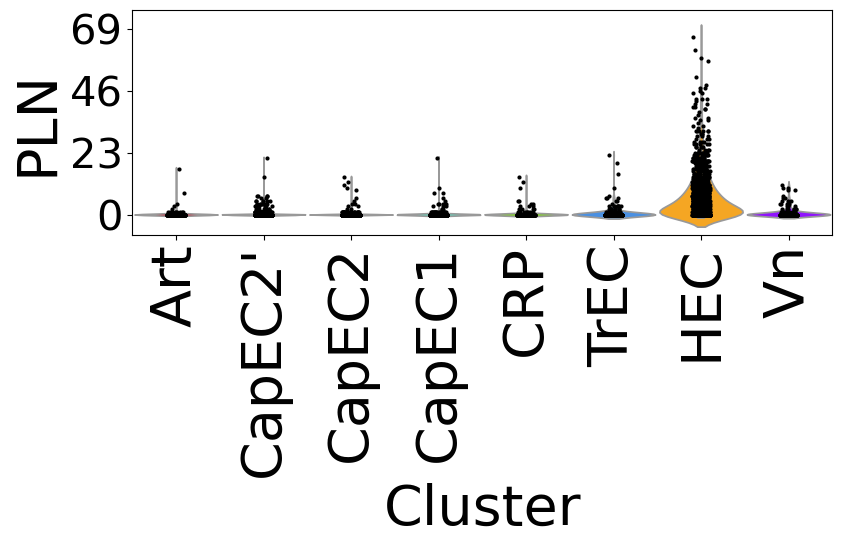

--------------- MLN ---------------


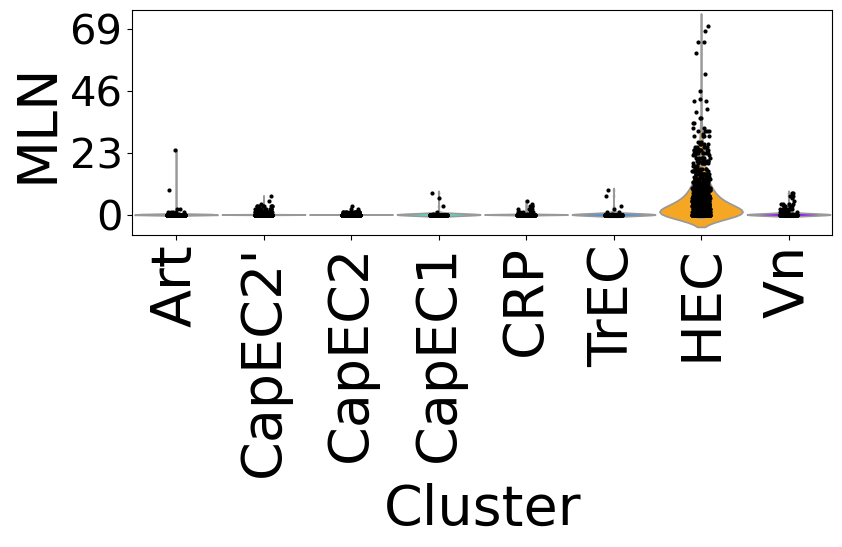

--------------- PP ---------------


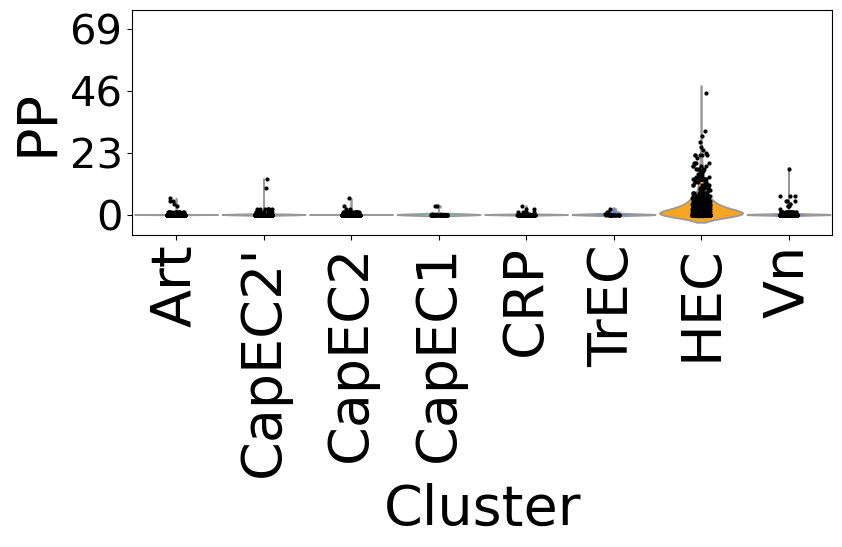

############### Robo2 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


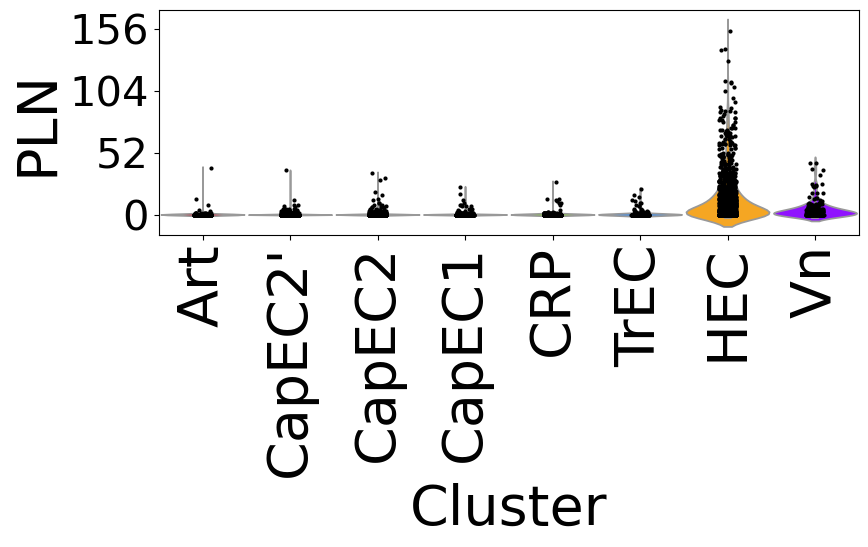

--------------- MLN ---------------


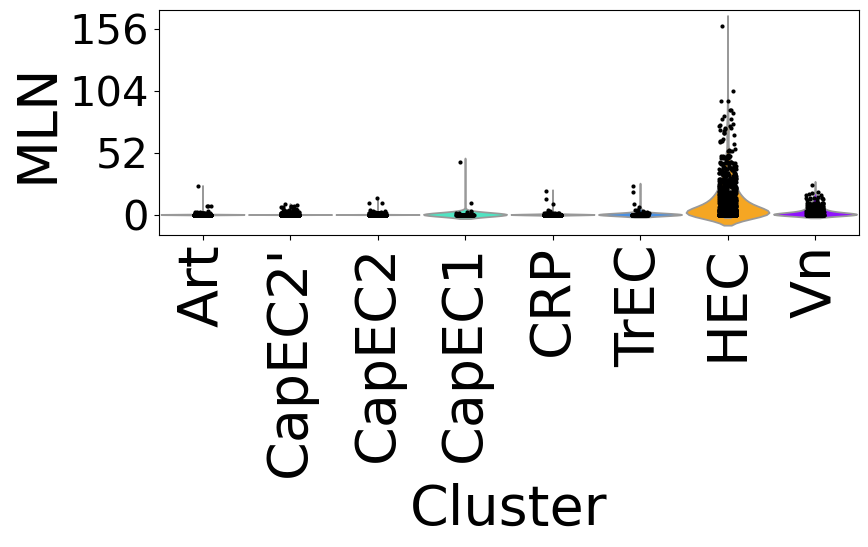

--------------- PP ---------------


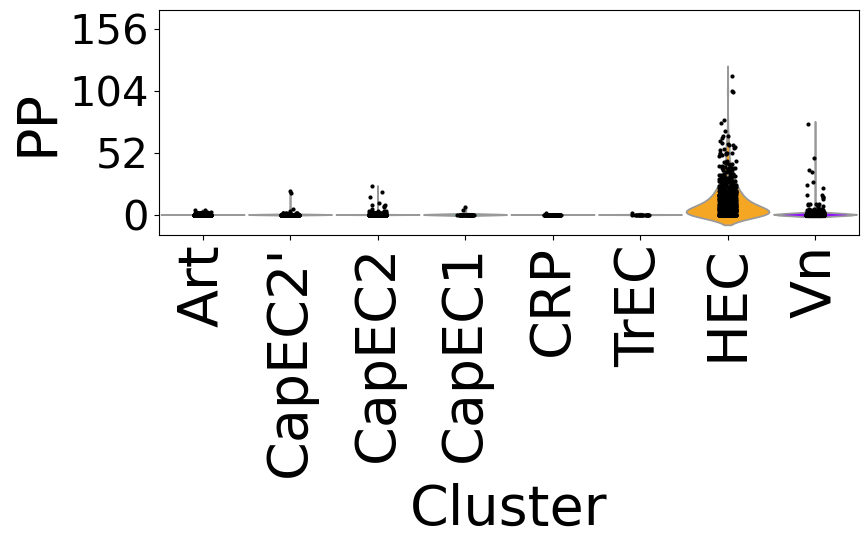

############### Sulf1 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


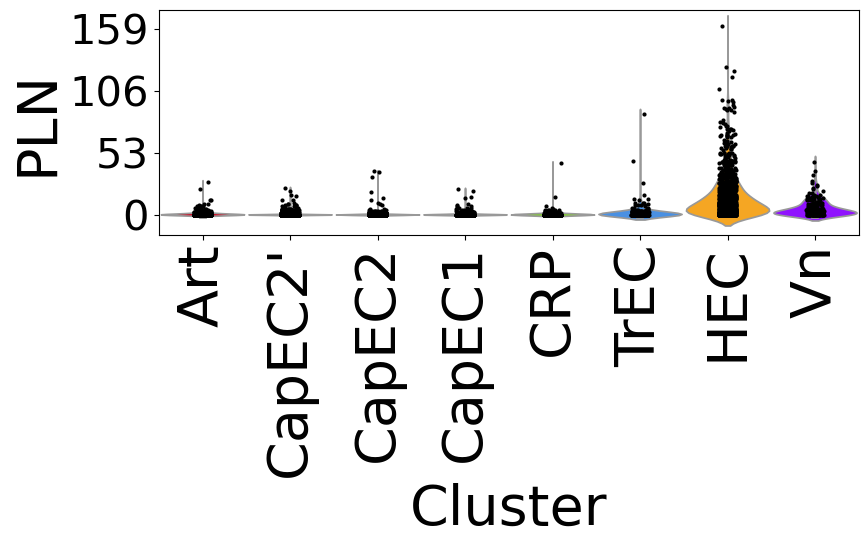

--------------- MLN ---------------


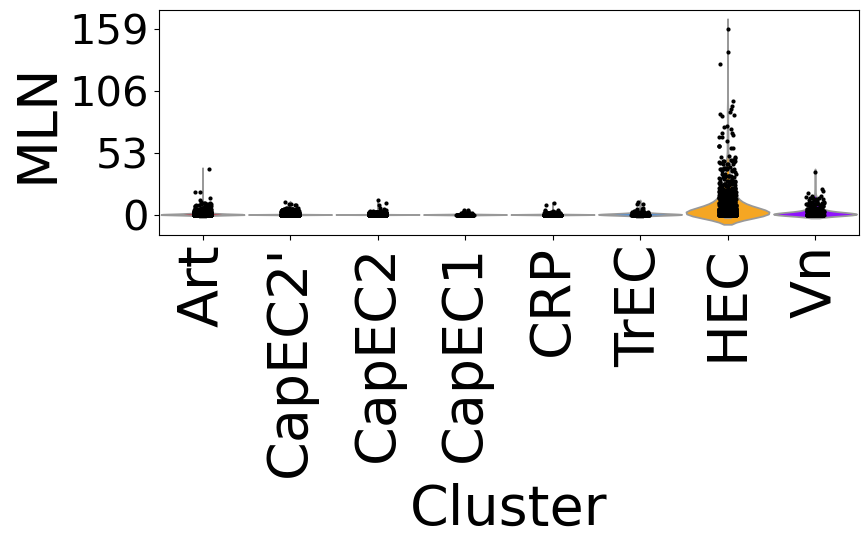

--------------- PP ---------------


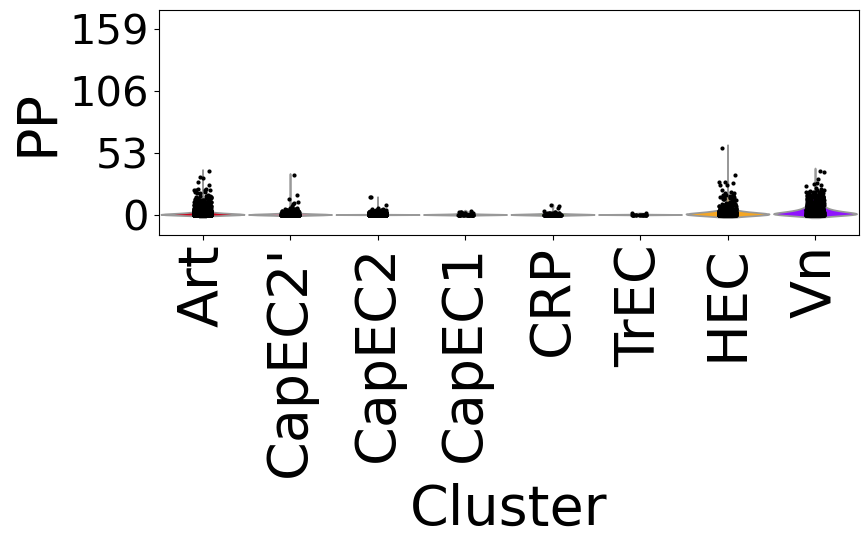

############### Ccl21a ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


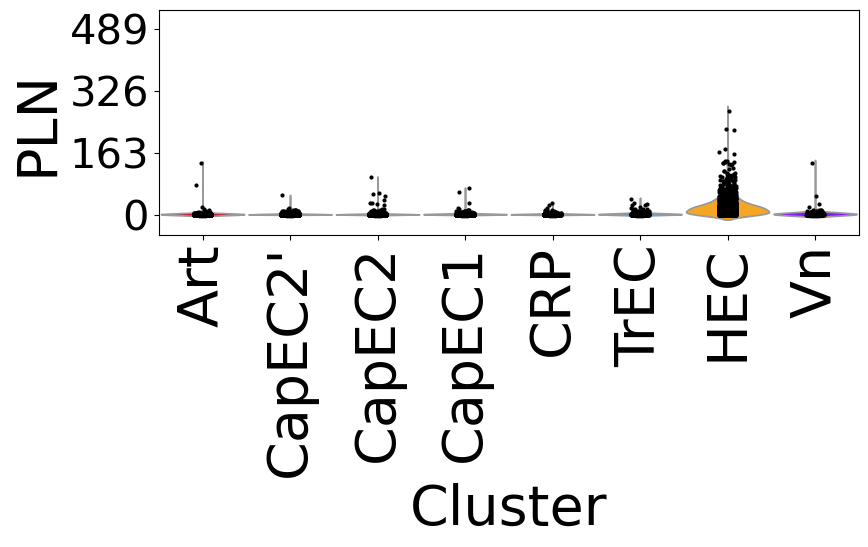

--------------- MLN ---------------


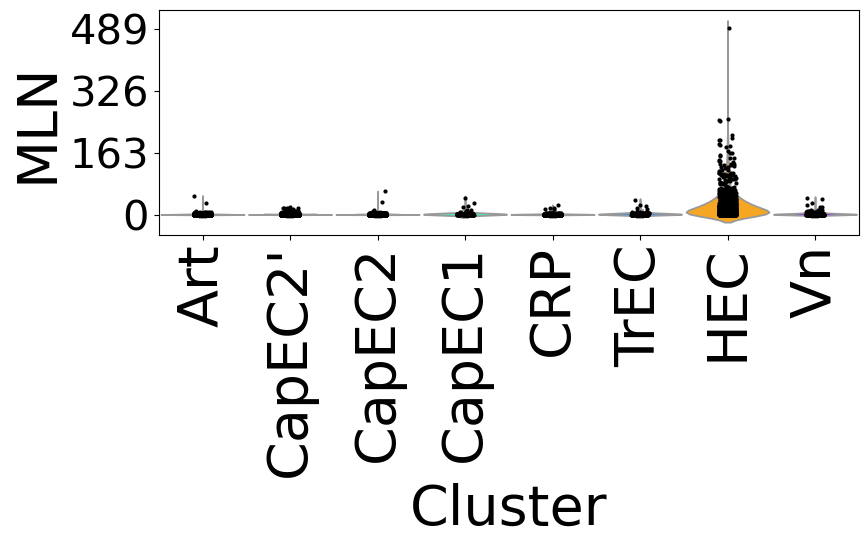

--------------- PP ---------------


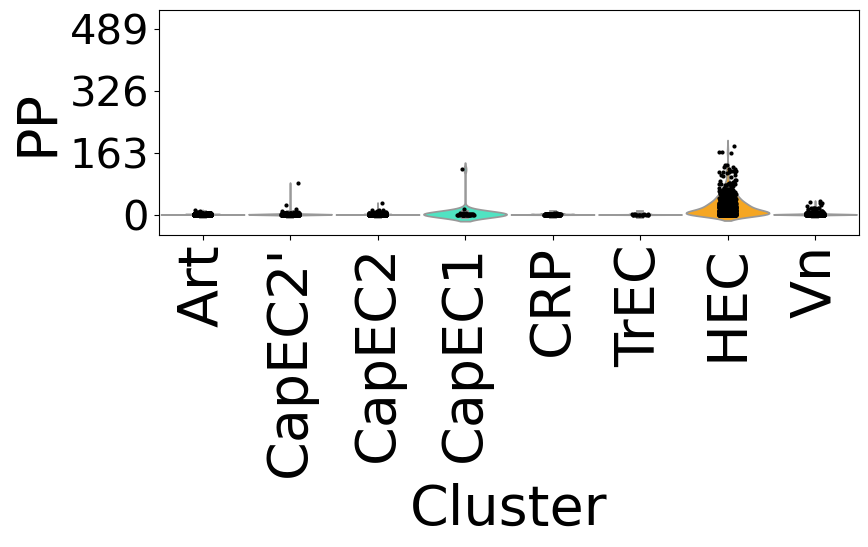

############### Stra6 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


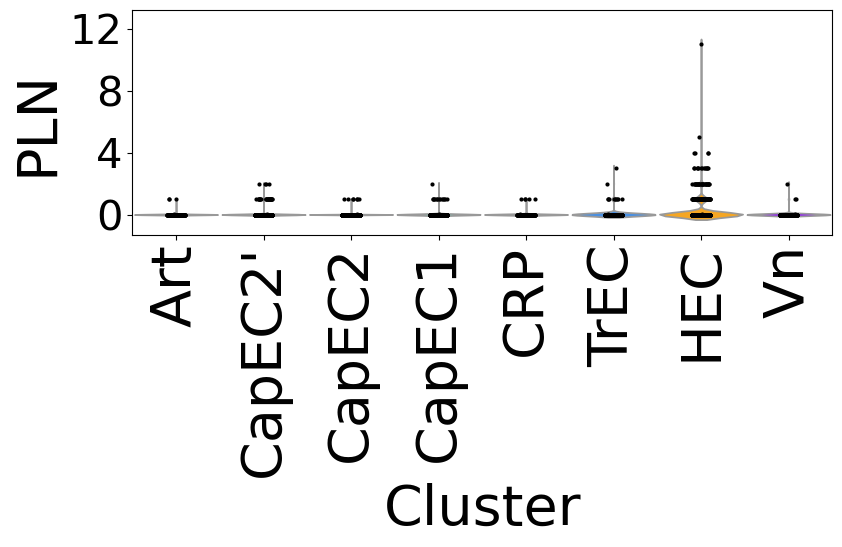

--------------- MLN ---------------


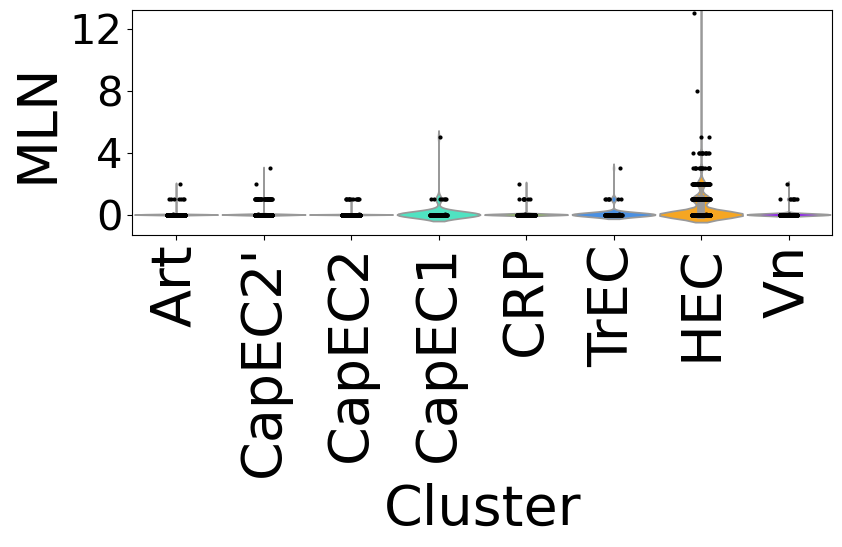

--------------- PP ---------------


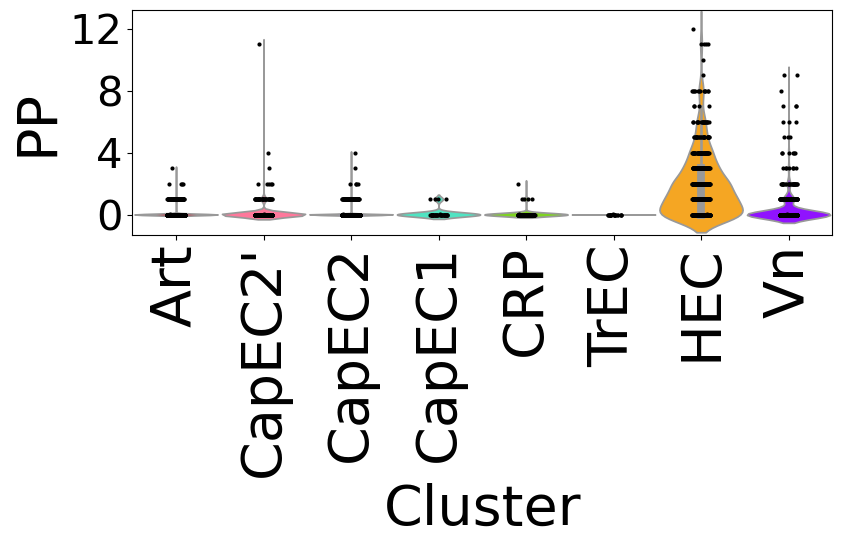

############### Madcam1 ###############
... reading from cache file cache/Seurat-PLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-MLN-data2-matrix.h5ad
... reading from cache file cache/Seurat-PP-data2-matrix.h5ad
--------------- PLN ---------------


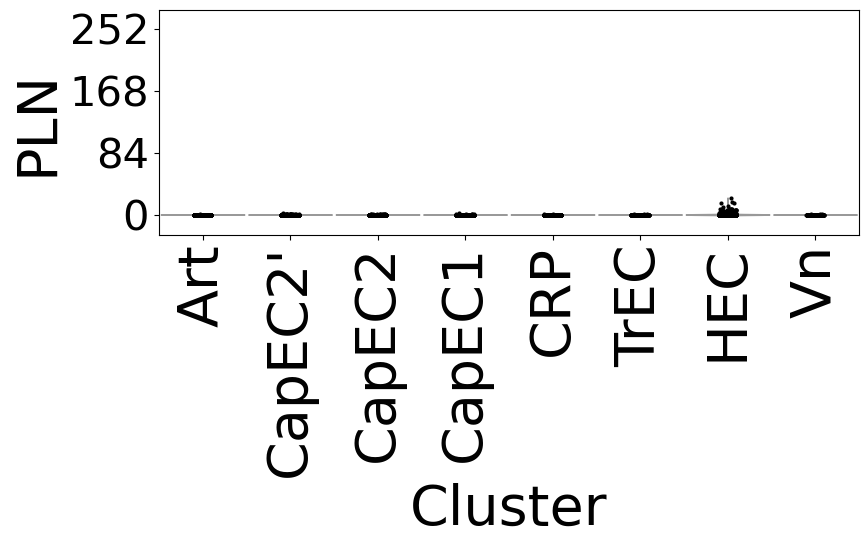

--------------- MLN ---------------


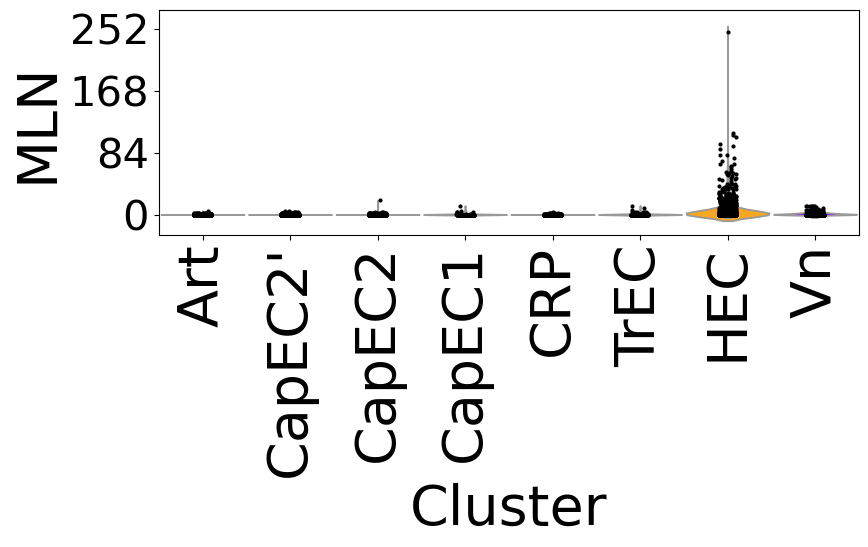

--------------- PP ---------------


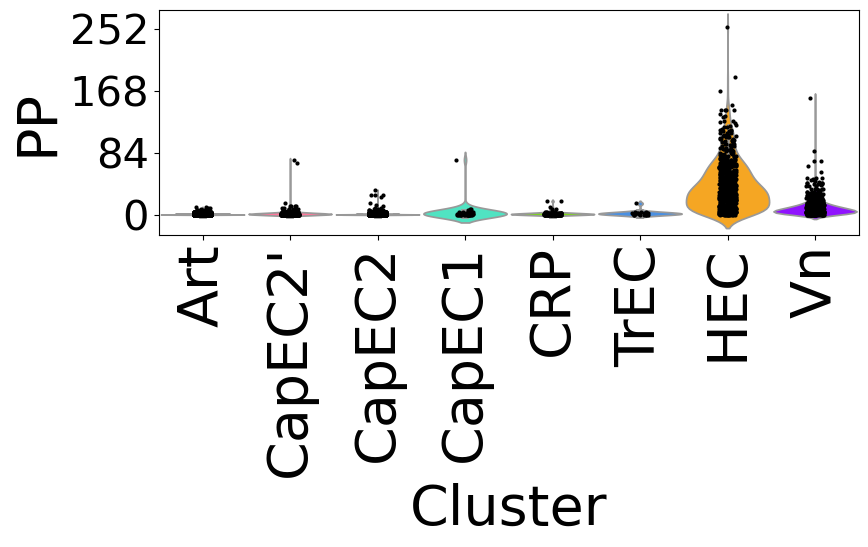

In [260]:
# Fig1(c)
clusters = [1, 3, 4, 5, 6, 7, 8, 9]
genes = [
    'Chst4', 'Fut7', 'Gcnt1', 'Madcam1'
]

for gene in genes:
    print(f'############### {gene} ###############')
    
    df = {}
    adata_pln = load_data('PLN')
    df['PLN'] = make_df(adata_pln, cdef, gene, clusters)
    adata_mln = load_data('MLN')
    df['MLN'] = make_df(adata_mln, cdef, gene, clusters)
    adata_pp = load_data('PP')
    df['PP'] = make_df(adata_pp, cdef, gene, clusters)
    
    max_v_pln = df['PLN'][gene].max()
    max_v_mln = df['MLN'][gene].max()
    max_v_pp = df['PP'][gene].max()
    max_v = max(max_v_pln, max_v_mln, max_v_pp)
    
    y_max = (max_v // 3) * 4.4 * 0.75
    y_min = -1 * (y_max / 10)
    y_unit = max_v // 3
    
    for tissue in ['PLN', 'MLN', 'PP']:
        print(f'--------------- {tissue} ---------------')
        violin_plot(df[tissue], tissue, gene, y_min, y_max, y_unit, f'{Fig1c}_{gene}_{tissue}.png')

In [ ]:
# Supplementary_Fig1
clusters = [1, 3, 4, 5, 6, 7, 8, 9]
genes = [
    'Glycam1', 'Csmd1', 'Clu', 'Ttn',
    "Ndst3", "Robo1", "Robo2", "Sulf1", "Ccl21a", "Stra6"
]

for gene in genes:
    print(f'############### {gene} ###############')
    
    df = {}
    adata_pln = load_data('PLN')
    df['PLN'] = make_df(adata_pln, cdef, gene, clusters)
    adata_mln = load_data('MLN')
    df['MLN'] = make_df(adata_mln, cdef, gene, clusters)
    adata_pp = load_data('PP')
    df['PP'] = make_df(adata_pp, cdef, gene, clusters)
    
    max_v_pln = df['PLN'][gene].max()
    max_v_mln = df['MLN'][gene].max()
    max_v_pp = df['PP'][gene].max()
    max_v = max(max_v_pln, max_v_mln, max_v_pp)
    
    y_max = (max_v // 3) * 4.4 * 0.75
    y_min = -1 * (y_max / 10)
    y_unit = max_v // 3
    
    for tissue in ['PLN', 'MLN', 'PP']:
        print(f'--------------- {tissue} ---------------')
        violin_plot(df[tissue], tissue, gene, y_min, y_max, y_unit, f'{Supplementary_Fig1}_{gene}_{tissue}.png')